***House Price Prediction***

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns







In [8]:
#loaded the dataset
df = pd.read_csv("Housing.csv")


***EDA***

In [9]:
#Check first five row to see what the data looks like
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [10]:
df.shape


(545, 13)

In [11]:
df.columns


Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [13]:
#it summarizes all numerical columns

df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [14]:
#Checking missing value
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [15]:
#checking duplicate rows
df.duplicated().sum()

np.int64(0)

*Check The unique Values of categorical features* machin model cannot understand words so unique () tells us what words in the columns and encod using Labelencoder

In [16]:
df["mainroad"].unique()


<StringArray>
['yes', 'no']
Length: 2, dtype: str

In [17]:
df["guestroom"].unique()


<StringArray>
['no', 'yes']
Length: 2, dtype: str

In [18]:
df["basement"].unique()


<StringArray>
['no', 'yes']
Length: 2, dtype: str

In [19]:
df["hotwaterheating"].unique()


<StringArray>
['no', 'yes']
Length: 2, dtype: str

In [20]:
df["airconditioning"].unique()


<StringArray>
['yes', 'no']
Length: 2, dtype: str

In [21]:
df["prefarea"].unique()


<StringArray>
['yes', 'no']
Length: 2, dtype: str

In [22]:
df["furnishingstatus"].unique()

<StringArray>
['furnished', 'semi-furnished', 'unfurnished']
Length: 3, dtype: str

***Visualization***

Distribution of House Prices 


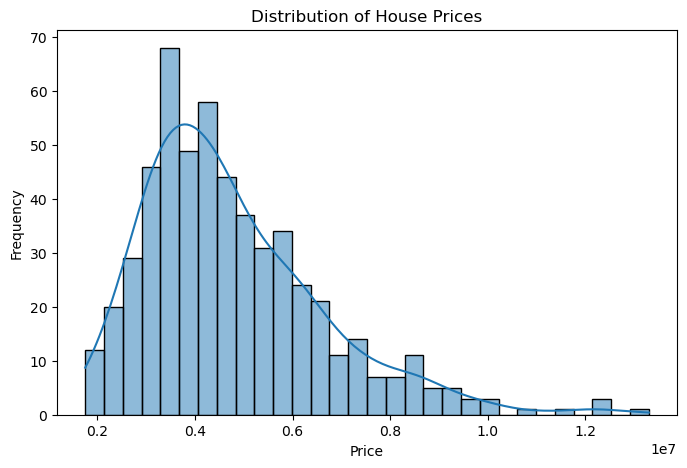

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(df["price"], bins=30, kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [27]:
#Relationship Between Area and price


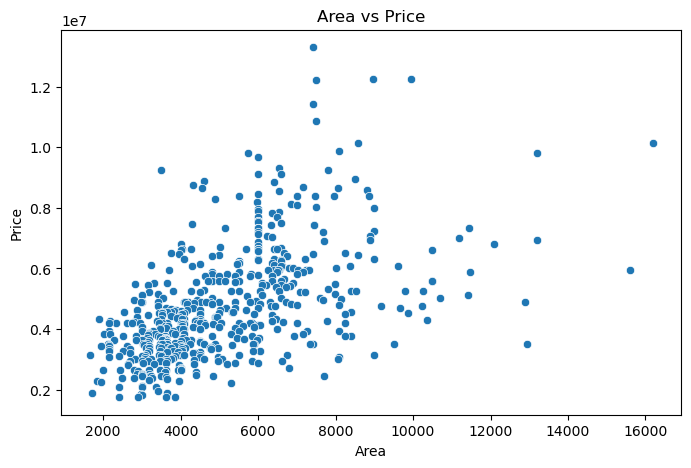

In [24]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="area", y="price", data=df)
plt.title("Area vs Price")
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()

Bathrooms vs Price


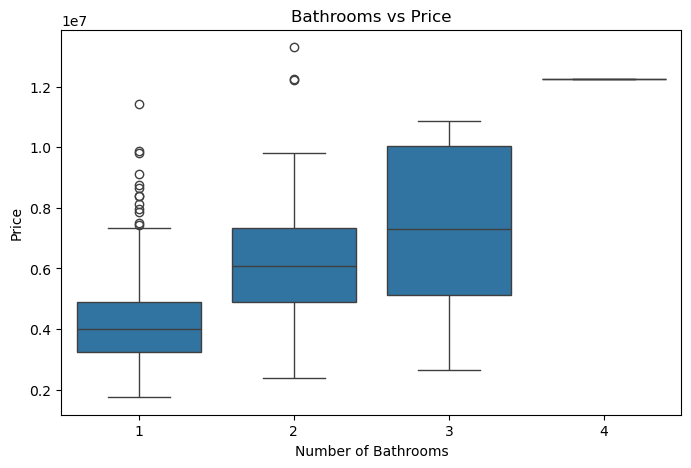

In [25]:
plt.figure(figsize=(8,5))
sns.boxplot(x="bathrooms", y="price", data=df)
plt.title("Bathrooms vs Price")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Price")
plt.show()

Furnishing Status vs Price

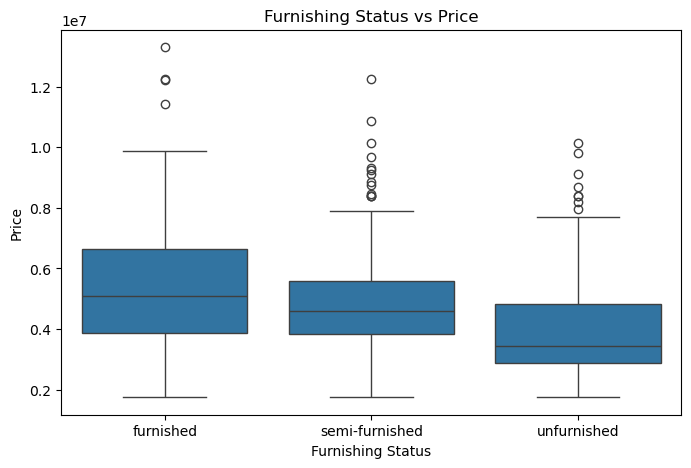

In [26]:
plt.figure(figsize=(8,5))
sns.boxplot(x="furnishingstatus", y="price", data=df)
plt.title("Furnishing Status vs Price")
plt.xlabel("Furnishing Status")
plt.ylabel("Price")
plt.show()

***Correlation Matrix***

In [24]:
#before creating heatmap, we must categorical cloumns into numbers b/c correlation works only with numeric data
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

encoder = LabelEncoder()

categorical_columns = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea",
    "furnishingstatus"
]

for col in categorical_columns:
    df_encoded[col] = encoder.fit_transform(df_encoded[col])

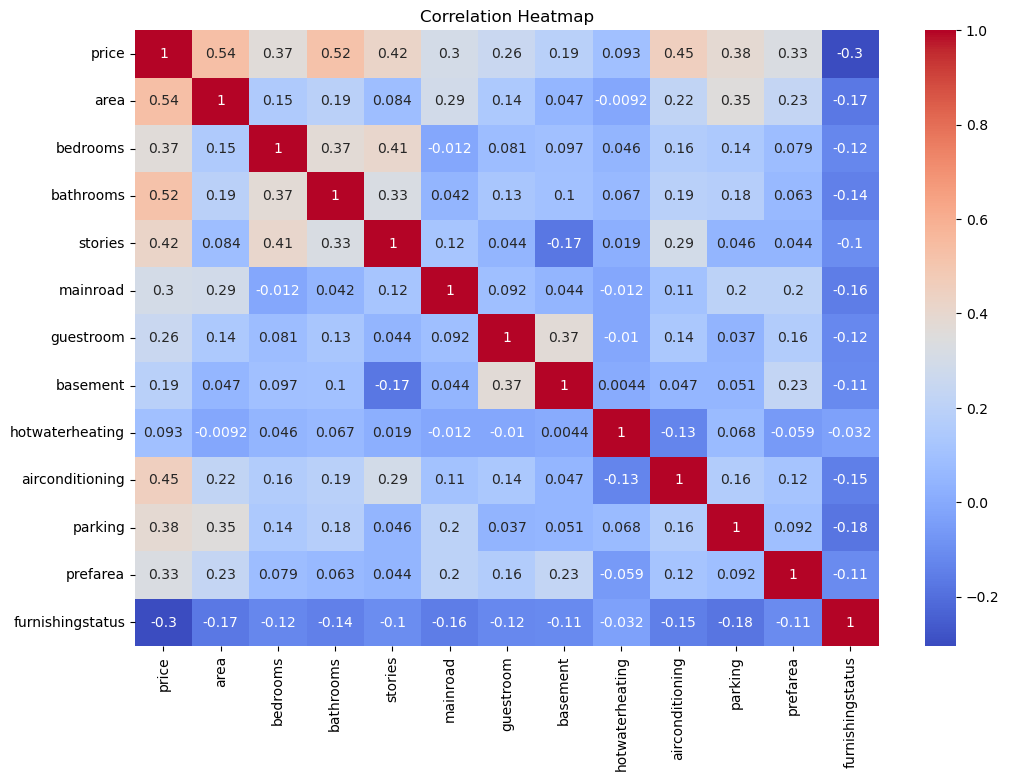

In [25]:
#correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df_encoded.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [26]:
#it tells us which most important faetures is highest and lowest collreation price vs all features
df_encoded.corr()["price"].sort_values(ascending=False)

price               1.000000
area                0.535997
bathrooms           0.517545
airconditioning     0.452954
stories             0.420712
parking             0.384394
bedrooms            0.366494
prefarea            0.329777
mainroad            0.296898
guestroom           0.255517
basement            0.187057
hotwaterheating     0.093073
furnishingstatus   -0.304721
Name: price, dtype: float64

***Prepare The Data***

In [27]:
#Creating Variable y tareget variabel (what we predict)
y = df_encoded["price"]

In [28]:
#Univariate Regression: area(highest positive correlation) , inputs
X1 = df_encoded[["area"]]

In [29]:
#Bivariate Regression: area and bathrooms(two strongest correlated features), inputs
X2 = df_encoded[["area", "bathrooms"]]

In [30]:
#Multivariate Regression:(all features except price), inputs
X3 = df_encoded.drop("price", axis=1)

***Split The data***

Model 1

In [31]:
from sklearn.model_selection import train_test_split

X1_train, X1_test, y_train, y_test = train_test_split(
    X1,
    y,
    test_size=0.2,
    random_state=42
)

Model 2

In [33]:
from sklearn.model_selection import train_test_split

X2_train, X2_test, y_train, y_test = train_test_split(
    X2,
    y,
    test_size=0.2,
    random_state=42
)

Model 3

In [34]:
from sklearn.model_selection import train_test_split

X3_train, X3_test, y_train, y_test = train_test_split(
    X3,
    y,
    test_size=0.2,
    random_state=42
)

In [40]:
X1_train.shape


(436, 1)

In [41]:
X1_test.shape


(109, 1)

In [42]:
X2_train.shape


(436, 2)

In [43]:
X2_test.shape


(109, 2)

In [38]:
X3_train.shape


(436, 12)

In [39]:
X3_test.shape

(109, 12)

***Train The Univariate Regression Model***

In [44]:

from sklearn.linear_model import LinearRegression

In [45]:
#Create the model(it creats an empty linear regression model)
model1 = LinearRegression()

In [46]:
#Train the model
model1.fit(X1_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [47]:
#Make predictions
pred1 = model1.predict(X1_test)

In [48]:
#The first 10 predicted prices
pred1[:10]

array([5024060.33139816, 5279498.23656143, 4232202.82539203,
       4640903.47365326, 4198144.43803692, 5373158.80178796,
       6139472.51727777, 4636646.17523387, 3891618.951841  ,
       3661724.83719406])

Compare predicted and actual prices

In [50]:
from sklearn.linear_model import LinearRegression

model1 = LinearRegression()

model1.fit(X1_train, y_train)

pred1 = model1.predict(X1_test)

comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": pred1
})

comparison.head(10)

,Actual Price,Predicted Price
0,4060000,5.024060e+06
1,6650000,5.279498e+06
2,3710000,4.232203e+06
3,6440000,4.640903e+06
4,2800000,4.198144e+06
5,4900000,5.373159e+06
6,5250000,6.139473e+06
7,4543000,4.636646e+06
8,2450000,3.891619e+06
9,3353000,3.661725e+06


*Evaluate the univariate regression*

In [4]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [52]:
#Mean Absolute error(MAE)
mae1 = mean_absolute_error(y_test, pred1)
print("MAE:", mae1)

MAE: 1474748.1337969352


In [53]:
#Mean squared error (MSE)
mse1 = mean_squared_error(y_test, pred1)
print("MSE:", mse1)

MSE: 3675286604768.185


In [54]:
#root mean squared error
rmse1 = np.sqrt(mse1)
print("RMSE:", rmse1)

RMSE: 1917103.7021424233


In [55]:
#Coefficient of determination
r2_1 = r2_score(y_test, pred1)
print("R² Score:", r2_1)

R² Score: 0.27287851871974644


In [56]:
#all metrics together
print("MAE :", mae1)
print("MSE :", mse1)
print("RMSE:", rmse1)
print("R²  :", r2_1)

MAE : 1474748.1337969352
MSE : 3675286604768.185
RMSE: 1917103.7021424233
R²  : 0.27287851871974644


***Bivariate Regression Model***

Train the model

In [57]:
from sklearn.linear_model import LinearRegression

model2 = LinearRegression()

model2.fit(X2_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [58]:
#predictions
pred2 = model2.predict(X2_test)

In [59]:
#Evaluate the model
mae2 = mean_absolute_error(y_test, pred2)
mse2 = mean_squared_error(y_test, pred2)
rmse2 = np.sqrt(mse2)
r2_2 = r2_score(y_test, pred2)

print("MAE :", mae2)
print("MSE :", mse2)
print("RMSE:", rmse2)
print("R²  :", r2_2)

MAE : 1295658.1544137204
MSE : 2885313513570.457
RMSE: 1698621.0623827956
R²  : 0.4291673924903032


*The bivariate regression model performed better than the univariate model. By adding the number of bathrooms as a second feature, the model improved in all evaluation metrics. The R² score increased from 0.273 to 0.429, showing that the model can now explain more variation in house prices.*

***Multivariate Regression Model (all features)***

Train the model

In [60]:
model3 = LinearRegression()
model3.fit(X3_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [61]:
#predict
pred3 = model3.predict(X3_test)

In [62]:
#Evaluate
mae3 = mean_absolute_error(y_test, pred3)
mse3 = mean_squared_error(y_test, pred3)
rmse3 = np.sqrt(mse3)
r2_3 = r2_score(y_test, pred3)

print("MAE :", mae3)
print("MSE :", mse3)
print("RMSE:", rmse3)
print("R²  :", r2_3)

MAE : 979679.6912959903
MSE : 1771751116594.0342
RMSE: 1331071.4167895103
R²  : 0.6494754192267805


In [36]:
#  comparison table for the three models

comparison_table = pd.DataFrame({
    "Model": ["Univariate Regression", "Bivariate Regression", "Multivariate Regression"],
    "Features Used": ["area", "area + bathrooms", "All Features"],
    "MAE": [1474748.1337969352, 1295658.1544137204, 979679.6912959903],
    "MSE": [3675286604768.185, 2885313513570.457, 1771751116594.0342],
    "RMSE": [1917103.7021424233, 1698621.0623827956, 1331071.4167895103],
    "R² Score": [0.27287851871974644, 0.4291673924903032, 0.6494754192267805]
})

comparison_table

,Model,Features Used,MAE,MSE,RMSE,R² Score
0,Univariate Regression,area,1.474748e+06,3.675287e+12,1.917104e+06,0.272879
1,Bivariate Regression,area + bathrooms,1.295658e+06,2.885314e+12,1.698621e+06,0.429167
2,Multivariate Regression,All Features,9.796797e+05,1.771751e+12,1.331071e+06,0.649475


***Three regression models  developed to predict house prices: The Univariate Regression Model had the lowest performance because it used only one feature (area),Bivariate Regression Model improved performance by adding one feature the bathrooms feature,Multivariate Regression Model achieved the best performance, with the lowest MAE, MSE, and RMSE and the highest R² score (0.649). The performance of each model was evaluated using MAE, RMSE, and R² score. The results show  the multivariate regression model performed best with the highest R² score of 0.649 and the lowest error values. This indicates that using all available features improves prediction accuracy because house prices are influenced by multiple factors. Therefore, the multivariate regression model is the most suitable model for predicting house prices in this dataset.***